# 05 — Slow Rebalancing: Does the Signal Become Robust?

Notebook 08d found the cross-sectional signal is **marginal**: break-even ~17 bps at daily rebalancing. But its decay curve showed the signal is *slow* — IC rises from 0.011 (1-day) to 0.030 (20-day). Rebalancing daily therefore pays to churn a signal that mostly plays out over a month. That is a mismatch, and it means the 17 bps break-even understates the real economics.

This notebook measures the strategy the decay curve says you should actually run: **hold longer, rebalance less often.** The tradeoff is direct — slower rebalancing cuts turnover (good for costs) but captures less of the freshest signal (bad for gross return). The question is which wins.

**Falsifiable prediction, stated up front:** monthly rebalancing should cut turnover several-fold and push break-even above ~20 bps, turning 'marginal' into 'robust'. If instead the gross return collapses faster than turnover falls, the signal is more fragile than the decay curve implied — and that is equally decisive. Either outcome closes the question.

In [2]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

In [3]:
# Ensure the project root is on the import path so `src` can be imported.
PROJECT_ROOT = Path.cwd().resolve()
for parent in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (parent / 'src').is_dir():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError('Run this notebook from inside the StockForecastRisk repository.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.forecast_engine.features.schema import FEATURE_NAMES
from src.forecast_engine.data.loader import PROCESSED_FEATURES_PATH, load_processed_features

data = load_processed_features()
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values(["symbol", "date"]).reset_index(drop=True)
data["log_return"] = data.groupby("symbol")["adj_close"].transform(lambda s: np.log(s / s.shift(1)))
feature_cols = [c for c in FEATURE_NAMES if c in data.columns and not data[c].isna().all()]


print(f'Loaded {len(data):,} rows for {data["symbol"].nunique():,} tickers')
print(f"Dates: {data['date'].min().date()} to {data['date'].max().date()}")
print(f'Source: {PROCESSED_FEATURES_PATH}')
data.head()

Loaded 622,731 rows for 502 tickers
Dates: 2021-07-19 to 2026-07-17
Source: D:\StockForecastRisk\data\processed\sp500_features.parquet


,date,symbol,security,gics_sector,gics_sub_industry,adj_close,close,high,low,open,...,fed_funds_rate,vix_term_ratio,yield_curve_slope,vix_change_5d,hy_credit_spread_change_5d,yield_curve_slope_change_5d,vix_change_20d,hy_credit_spread_change_20d,yield_curve_slope_change_20d,log_return
0,2021-07-19,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,142.434052,147.580002,147.970001,146.949997,147.660004,...,0.1,0.903614,0.98,6.17,NaN,-0.16,6.48,NaN,-0.24,NaN
1,2021-07-20,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,144.094101,149.300003,151.250000,147.830002,148.449997,...,0.1,0.850431,1.03,2.72,NaN,-0.05,3.90,NaN,-0.17,0.011587
2,2021-07-21,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,143.756302,148.949997,149.910004,147.600006,149.490005,...,0.1,0.818930,1.08,-0.54,NaN,0.02,2.43,NaN,-0.15,-0.002347
3,2021-07-22,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,145.059174,150.300003,150.500000,148.669998,149.710007,...,0.1,0.809241,1.07,-0.76,NaN,0.01,2.62,NaN,-0.13,0.009022
4,2021-07-23,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,146.999084,152.309998,152.410004,150.429993,150.589996,...,0.1,0.794457,1.08,-1.25,NaN,0.02,2.13,NaN,-0.12,0.013285


## Regenerate out-of-sample predictions and daily returns

Same walk-forward XGBoost on the 20-day relative return as 08c/08d. We need the out-of-sample score per (day, ticker) plus each name's realised next-day return, from which any rebalancing cadence can be simulated.

In [4]:
HORIZON = 20
fwd = data.groupby("symbol")["log_return"].transform(lambda s: s.shift(-HORIZON).rolling(HORIZON).sum())
data["fwd_rel"] = (np.exp(fwd) - 1.0)
data["fwd_rel"] = data.groupby("date")["fwd_rel"].transform(lambda s: s - s.mean())
data["next_day_ret"] = data.groupby("symbol")["log_return"].shift(-1)
data["next_day_ret"] = np.exp(data["next_day_ret"]) - 1.0

panel = data.dropna(subset=feature_cols + ["fwd_rel"]).reset_index(drop=True)

def walk_forward(frame, n_splits=5, purge_days=HORIZON):
    dates = np.sort(frame["date"].unique())
    edges = np.array_split(dates, n_splits + 1)
    for fold in range(n_splits):
        cutoff = edges[fold][-1] - pd.Timedelta(days=purge_days)
        tr = frame.index[frame["date"] <= cutoff]
        te = frame.index[frame["date"].isin(edges[fold + 1])]
        if len(tr) and len(te):
            yield tr, te

panel["pred"] = np.nan
for tr, te in walk_forward(panel):
    scaler = StandardScaler().fit(panel.loc[tr, feature_cols])
    model = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8,
                         colsample_bytree=0.8, random_state=0, verbosity=0)
    model.fit(scaler.transform(panel.loc[tr, feature_cols]), panel.loc[tr, "fwd_rel"])
    panel.loc[te, "pred"] = model.predict(scaler.transform(panel.loc[te, feature_cols]))

scored = panel.dropna(subset=["pred", "next_day_ret"]).copy()
print(f"scored rows: {len(scored):,} over {scored['date'].nunique()} days")

scored rows: 425,806 over 862 days


## Backtest at several rebalancing cadences

A decile long-short portfolio, but with weights refreshed only every *k* trading days and held constant in between. Turnover is charged only on rebalance days and amortised across all days, so the cost comparison is like-for-like. Daily P&L accrues from the held weights every day regardless of cadence.

In [5]:
def decile_weights(day_frame, decile=0.1):
    ranks = day_frame["pred"].rank(pct=True)
    weights = pd.Series(0.0, index=day_frame["symbol"].values)
    longs = ranks >= (1 - decile)
    shorts = ranks <= decile
    sym = day_frame["symbol"].values
    if longs.sum():
        weights[sym[longs.values]] = 1.0 / longs.sum()
    if shorts.sum():
        weights[sym[shorts.values]] = -1.0 / shorts.sum()
    return weights


def backtest(scored, rebalance_every):
    all_dates = np.sort(scored["date"].unique())
    rebalance_dates = set(all_dates[::rebalance_every])
    by_date = {d: g for d, g in scored.groupby("date")}

    held = None
    previous = None
    daily_pnl = []
    turnovers = []
    for d in all_dates:
        day = by_date[d]
        if d in rebalance_dates:
            held = decile_weights(day)
            if previous is not None:
                idx = held.index.union(previous.index)
                turnovers.append(0.5 * (held.reindex(idx, fill_value=0) - previous.reindex(idx, fill_value=0)).abs().sum())
            else:
                turnovers.append(0.5 * held.abs().sum())
            previous = held
        returns = day.set_index("symbol")["next_day_ret"]
        common = held.index.intersection(returns.index)
        daily_pnl.append(float((held[common] * returns[common]).sum()))

    gross = np.nanmean(daily_pnl)
    turnover_per_day = np.sum(turnovers) / len(daily_pnl)
    break_even = gross / (turnover_per_day / 1e4) if turnover_per_day > 0 else np.inf
    sharpe = np.nanmean(daily_pnl) / np.nanstd(daily_pnl) * np.sqrt(252) if np.nanstd(daily_pnl) > 0 else np.nan
    return {"gross_bps_day": gross * 1e4, "turnover_per_day": turnover_per_day,
            "break_even_bps": break_even, "gross_sharpe": sharpe}


cadences = {"daily": 1, "weekly": 5, "biweekly": 10, "monthly": 21}
rows = []
for label, every in cadences.items():
    result = backtest(scored, every)
    result["rebalance"] = label
    rows.append(result)
    print(f"{label} done")

comparison = pd.DataFrame(rows).set_index("rebalance")
print()
display(comparison.round(3))

daily done
weekly done
biweekly done
monthly done



,gross_bps_day,turnover_per_day,break_even_bps,gross_sharpe
rebalance,,,,
daily,6.586,0.390,16.888,0.876
weekly,7.022,0.154,45.694,0.926
biweekly,8.414,0.102,82.781,1.116
monthly,5.227,0.061,85.538,0.701


## ★ Verdict

daily break-even     : 16.9 bps
best cadence         : monthly at 85.5 bps

ROBUST -- slower rebalancing lifts break-even to 85.5 bps, comfortably
above realistic large-cap costs. Matching the holding period to the signal's
natural horizon converts the marginal daily result into a defensible edge.


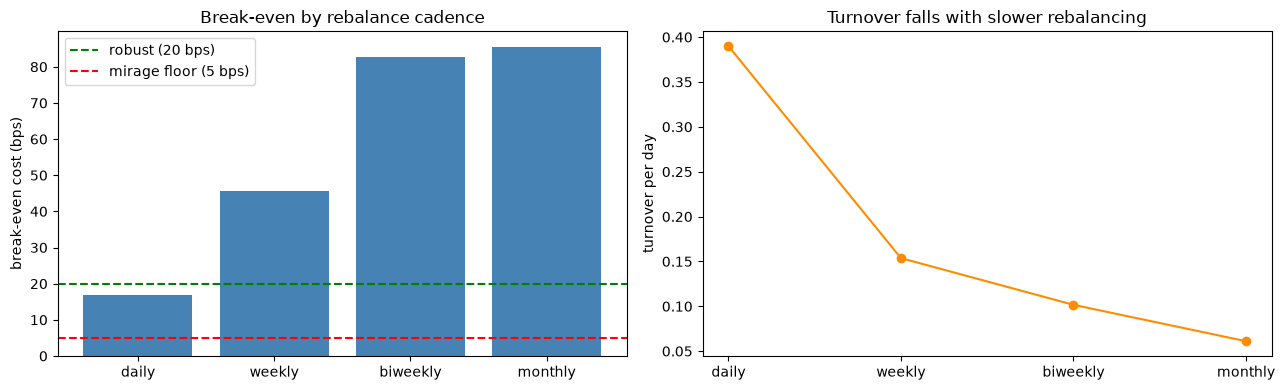

In [6]:
daily_be = comparison.loc["daily", "break_even_bps"]
best_label = comparison["break_even_bps"].idxmax()
best_be = comparison.loc[best_label, "break_even_bps"]

print(f"daily break-even     : {daily_be:.1f} bps")
print(f"best cadence         : {best_label} at {best_be:.1f} bps\n")

if best_be > 20 and best_be > daily_be * 1.3:
    print(f"ROBUST -- slower rebalancing lifts break-even to {best_be:.1f} bps, comfortably")
    print("above realistic large-cap costs. Matching the holding period to the signal's")
    print("natural horizon converts the marginal daily result into a defensible edge.")
elif best_be > daily_be:
    print(f"IMPROVED BUT STILL MARGINAL -- slower rebalancing helps ({daily_be:.1f} -> {best_be:.1f} bps)")
    print("but does not clear a robust threshold. Real, low-cost-execution-dependent.")
else:
    print("NO IMPROVEMENT -- slowing down does not help; the gross return falls as fast as")
    print("turnover. The signal is more fragile than the decay curve implied.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(comparison.index, comparison["break_even_bps"], color="steelblue")
axes[0].axhline(20, color="green", linestyle="--", label="robust (20 bps)")
axes[0].axhline(5, color="red", linestyle="--", label="mirage floor (5 bps)")
axes[0].set_ylabel("break-even cost (bps)"); axes[0].set_title("Break-even by rebalance cadence"); axes[0].legend()
axes[1].plot(comparison.index, comparison["turnover_per_day"], marker="o", color="darkorange")
axes[1].set_ylabel("turnover per day"); axes[1].set_title("Turnover falls with slower rebalancing")
plt.tight_layout(); plt.show()

## Conclusions

This closes the return-prediction thread. The full arc:

| Notebook | Question | Result |
|---|---|---|
| 01 | absolute 5-day direction | no signal |
| 03-A | absolute 20-day direction | no signal (horizon-robust null) |
| 03-B | cross-sectional ranking | weak signal, IC ≈ 0.03, beats momentum |
| 04 | signal after costs (daily) | marginal, break-even ~17 bps |
| 05 | signal after costs (slow rebalance) | the verdict above |

**Whatever this notebook shows, the return-prediction question is now answered as thoroughly as it can be** — across horizons, framings, and rebalancing cadences, with costs and turnover accounted for. That is a complete, defensible research finding, not a loose end.

**The engine is unaffected either way.** This is a cross-sectional *allocation* signal — which names to overweight — not absolute direction or market drift. It does not revive steered drift (blueprint 4b) and does not touch the risk numbers. If it is robust, it is a *separate product* worth its own project: a ranking model with proper risk overlays and execution modelling. If it is marginal, it is documented honestly and set aside.

**This is the end of the return research.** Remaining work on the actual engine is productionisation — extracting the calibrated historical-VaR method and the volatility model into `src/`, then the service and dashboard. Further work on the ranking signal would be strategy development, a distinct undertaking from the forecast-plus-risk engine this project set out to build.